# Options Quant — Sleeve Allocation Framework (α Engine, **local POC**)

Local twin of `sleeve_alpha.ipynb`. All-official free data: CBOE (SPX/VIX/VIX3M/SKEW/VXN) + FRED (NASDAQ100/DGS3MO). Produces the same identifier set so Section 2+ math copies back to the Cron2 notebook verbatim.

Universe: SPX (S&P 500 index) and NDX (NASDAQ-100 index). Full signal stack on both — iv30_90mny and NDX iv90_atm are synthesized from VIX/VXN/SKEW (POC; absolute level uncalibrated, monotonic enough for percentile-rank signals).


## Section 0 — Setup & Config


In [1]:
import pathlib
import warnings
import datetime as dt

import numpy as np
import pandas as pd
import pandas_market_calendars as mcal
import matplotlib.pyplot as plt

from local_data import con  # FreeCon — drop-in for Cron2 emds_client.con


In [2]:
UNDERLYINGS = {
    "SPX": "SPX Index",
    "NDX": "NDX Index",
}
REQUIRED_UNDERLYINGS = ("SPX", "NDX")

IV_FIELDS = {
    "iv30_atm":   "30DAY_IMPVOL_100.0%MNY_DF",
    "iv30_90mny": "30DAY_IMPVOL_90.0%MNY_DF",
    "iv90_atm":   "90DAY_IMPVOL_100.0%MNY_DF",
}
PRICE_FIELD = "PX_LAST"

CROSS_ASSET = {
    "vix":     ("VIX Index",     "PX_LAST"),
    "rf_rate": ("USGG3M Index",  "PX_LAST"),
}

START_DATE = "2010-01-01"
END_DATE   = dt.date.today().isoformat()


In [3]:
def nyse_index(start, end):
    sched = mcal.get_calendar("NYSE").schedule(start_date=start, end_date=end)
    return pd.DatetimeIndex(sched.index).normalize()

NYSE_INDEX = nyse_index(START_DATE, END_DATE)
print(f"NYSE_INDEX: n={len(NYSE_INDEX)}, {NYSE_INDEX.min().date()} → {NYSE_INDEX.max().date()}")


NYSE_INDEX: n=4108, 2010-01-04 → 2026-05-04


## Section 1 — Data Layer

### 1.1 Raw pulls (per-underlying, per-field)


In [4]:
raw_pulls = {u: {} for u in UNDERLYINGS}
for u, ticker in UNDERLYINGS.items():
    raw_pulls[u]["price"] = con.bdh(ticker, PRICE_FIELD, START_DATE, END_DATE)
    for fkey, fname in IV_FIELDS.items():
        raw_pulls[u][fkey] = con.bdh(ticker, fname, START_DATE, END_DATE)

pull_log = []
for u in UNDERLYINGS:
    for fkey, df in raw_pulls[u].items():
        pull_log.append({
            "underlying": u, "field": fkey,
            "n": len(df),
            "status": "landed" if len(df) else "deferred",
        })
pd.DataFrame(pull_log).pivot(index="underlying", columns="field", values="n").fillna(0).astype(int)


field,iv30_90mny,iv30_atm,iv90_atm,price
underlying,,,,
NDX,4102,4109,4107,4108
SPX,4102,4136,4107,4107


### 1.2 Cross-asset pulls


In [5]:
raw_cross = {}
for name, (ticker, field) in CROSS_ASSET.items():
    raw_cross[name] = con.bdh(ticker, field, START_DATE, END_DATE)

pd.DataFrame({
    "ticker": [CROSS_ASSET[k][0] for k in raw_cross],
    "n":      [len(raw_cross[k]) for k in raw_cross],
    "status": ["landed" if len(raw_cross[k]) else "deferred" for k in raw_cross],
}, index=list(raw_cross))


,ticker,n,status
vix,VIX Index,4136,landed
rf_rate,USGG3M Index,4084,landed


### 1.3 Panel assembly

Wide panels on `NYSE_INDEX`. Naming: `iv90mny` is the 90%-moneyness 30D IV (skew leg). `iv90_panel` is the 90D ATM IV probe. `skew_panel = iv90mny - iv_panel`. Truncated to the shortest IV history per D-04.


In [6]:
def _to_series(df, name):
    if df is None or len(df) == 0:
        return None
    s = df.squeeze()
    if isinstance(s, pd.DataFrame):
        s = s.iloc[:, 0]
    s.index = pd.DatetimeIndex(s.index).normalize()
    s.name = name
    return s

def _build_panel(field_key, underlyings_with_data):
    cols = {}
    for u in underlyings_with_data:
        s = _to_series(raw_pulls[u][field_key], u)
        if s is not None:
            cols[u] = s.reindex(NYSE_INDEX)
    return pd.DataFrame(cols, index=NYSE_INDEX)

landed = [
    u for u in UNDERLYINGS
    if len(raw_pulls[u].get("price", pd.DataFrame())) > 0
    and len(raw_pulls[u].get("iv30_atm", pd.DataFrame())) > 0
    and len(raw_pulls[u].get("iv30_90mny", pd.DataFrame())) > 0
]
print(f"Landed underlyings: {landed}")

prices_panel_full = _build_panel("price",      list(UNDERLYINGS))
iv_panel_full     = _build_panel("iv30_atm",   landed)
iv90mny_full      = _build_panel("iv30_90mny", landed)
iv90_panel_full   = _build_panel(
    "iv90_atm",
    [u for u in landed if len(raw_pulls[u].get("iv90_atm", pd.DataFrame())) > 0],
)

iv_first_dates = []
for u in landed:
    s = iv_panel_full[u].dropna()
    if len(s):
        iv_first_dates.append(s.index.min())
truncate_start = max(iv_first_dates) if iv_first_dates else NYSE_INDEX.min()
print(f"Truncating to start={truncate_start.date()} (shortest IV history)")

mask = NYSE_INDEX >= truncate_start
prices_panel = prices_panel_full.loc[mask].copy()
iv_panel     = iv_panel_full.loc[mask].copy()
iv90mny      = iv90mny_full.loc[mask].copy()
iv90_panel   = iv90_panel_full.loc[mask].copy()

common_skew_cols = [c for c in iv_panel.columns if c in iv90mny.columns]
skew_panel = iv90mny[common_skew_cols] - iv_panel[common_skew_cols]

pd.DataFrame({
    "prices_panel": prices_panel.notna().sum(),
    "iv_panel":     iv_panel.reindex(columns=prices_panel.columns).notna().sum(),
    "iv90_panel":   iv90_panel.reindex(columns=prices_panel.columns).notna().sum(),
    "skew_panel":   skew_panel.reindex(columns=prices_panel.columns).notna().sum(),
}).T


Landed underlyings: ['SPX', 'NDX']
Truncating to start=2010-01-04 (shortest IV history)


,SPX,NDX
prices_panel,4107,4107
iv_panel,4107,4107
iv90_panel,4107,4107
skew_panel,4102,4102


### 1.4 Cross-asset Series


In [7]:
def _to_named_series(name):
    df = raw_cross.get(name, pd.DataFrame())
    if df is None or len(df) == 0:
        s = pd.Series(index=NYSE_INDEX, dtype="float64", name=name)
    else:
        s = df.squeeze()
        if isinstance(s, pd.DataFrame):
            s = s.iloc[:, 0]
        s.index = pd.DatetimeIndex(s.index).normalize()
        s.name = name
        s = s.reindex(NYSE_INDEX)
    return s.loc[NYSE_INDEX >= truncate_start]

vix     = _to_named_series("vix")
rf_rate = _to_named_series("rf_rate")

for s in (vix, rf_rate):
    assert isinstance(s, pd.Series), f"{s.name} must be a Series, got {type(s)}"
    assert s.index.equals(prices_panel.index), f"{s.name} index mismatch"

pd.DataFrame({
    "n_obs":   [s.notna().sum() for s in (vix, rf_rate)],
    "first":   [s.dropna().index.min() if s.notna().any() else None for s in (vix, rf_rate)],
    "last":    [s.dropna().index.max() if s.notna().any() else None for s in (vix, rf_rate)],
    "latest":  [s.dropna().iloc[-1] if s.notna().any() else None for s in (vix, rf_rate)],
}, index=["vix","rf_rate"])


,n_obs,first,last,latest
vix,4107,2010-01-04,2026-05-01,16.99
rf_rate,4076,2010-01-04,2026-04-30,3.68


### 1.5 Quick visual sanity check


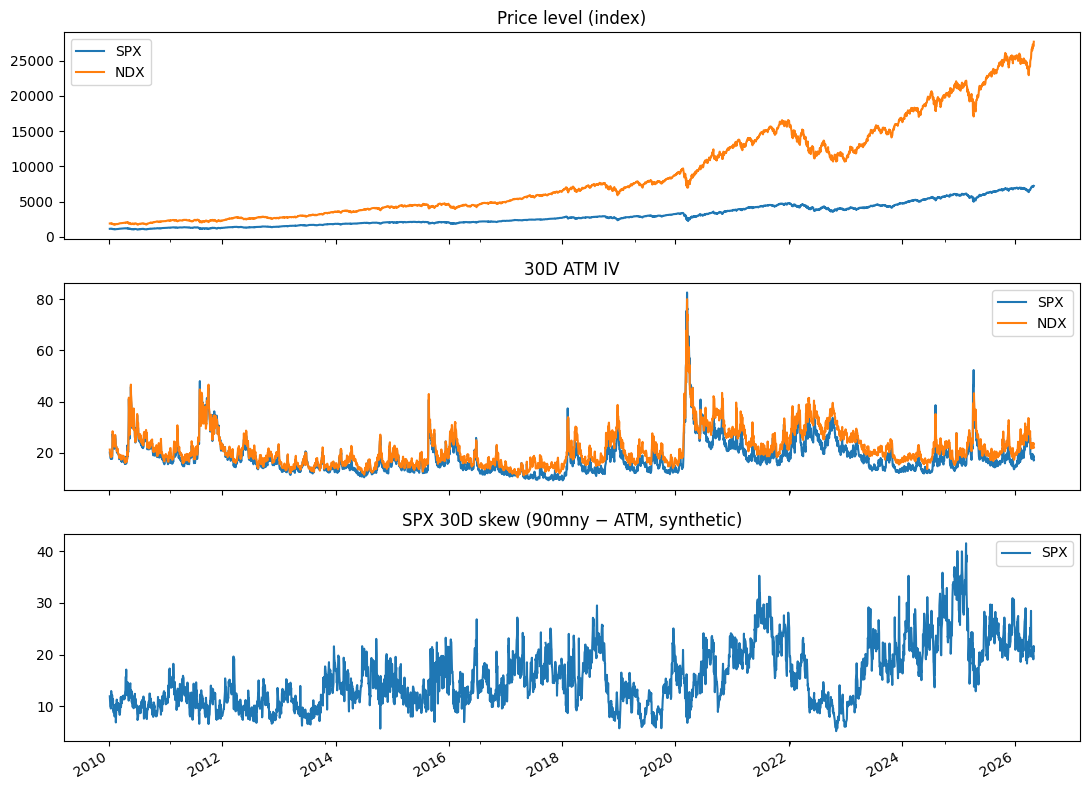

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
prices_panel[[c for c in ("SPX","NDX") if c in prices_panel.columns]].plot(ax=axes[0], title="Price level (index)")
iv_panel[[c for c in ("SPX","NDX") if c in iv_panel.columns]].plot(ax=axes[1], title="30D ATM IV")
if "SPX" in skew_panel.columns:
    skew_panel[["SPX"]].plot(ax=axes[2], title="SPX 30D skew (90mny − ATM, synthetic)")
plt.tight_layout()
plt.show()


## Section 2 — Signal Engineering *(next)*

Implements: realized vol (RV), VRP (IV − RV), term-structure slope (iv90_atm − iv30_atm), skew z-score, trend (200d SMA cross), drawdown depth, fragility composite.

All percentile-ranked within causal expanding-window history (no full-sample lookahead).
